#### Huấn luyện Model HỆ SỐ NHÂN — bộ TP.HCM

Dự đoán `target_shown_multiplier`. Notebook đi đủ các bước: **model là gì · cấu hình ban đầu · quá trình huấn
luyện · kết quả · đánh giá**.

> Train **theo từng tháng** (`evaluation_month`) rồi tổng hợp — đúng yêu cầu dataset (không gộp tháng).

**1. Model huấn luyện là gì**

Dùng **HistGradientBoosting** (gradient boosting cây quyết định, scikit-learn) cho bài hồi quy.

*Vì sao:* dữ liệu dạng bảng → cây thắng neural network; xử lý categorical + NaN native; giải thích
được; train nhanh CPU. Hệ số nhân dải hẹp (~1) → không cần log-target.

Feature: 4 categorical + 7 numeric (chốt từ notebook feature selection).

In [1]:
import warnings, time, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score
import joblib
warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({"figure.facecolor":"white","axes.spines.top":False,"axes.spines.right":False,
                     "axes.grid":True,"grid.color":"#ECECEC","font.size":10})
pd.set_option("display.width",200)

# Nap du lieu da chuan bi
PREP = Path("../data/hcm_train_ready.parquet")
assert PREP.exists(), "Chua co hcm_train_ready.parquet -> chay chuan_bi_du_lieu.ipynb truoc!"
df = pd.read_parquet(PREP)
print(f"Nap {len(df):,} dong")

TARGET = "target_shown_multiplier"
CAT = ["service_name", "pickup_location_name", "dropoff_location_name", "weather_main"]
NUM = ["pricing_market_imbalance_5m_lag", "pricing_demand_index_5m_lag", "pricing_supply_index_5m_lag", "pricing_quote_count_5m_lag", "latest_observed_multiplier", "gio_vn", "actual_observation_age_minutes"]
FEATS = CAT + NUM
LOG = False
print(f"Model HỆ SỐ NHÂN: target={TARGET} | {len(FEATS)} feature | log-target={LOG}")

def prep(d):
    X = d[FEATS].copy()
    for c in CAT: X[c] = X[c].astype("category")
    return X

Nap 6,897,051 dong
Model HỆ SỐ NHÂN: target=target_shown_multiplier | 11 feature | log-target=False


**2. Cấu hình ban đầu (siêu tham số)**

| Tham số | Giá trị | Ý nghĩa |
|---|---|---|
| max_iter | 500 | Số cây tối đa (số vòng boosting) |
| learning_rate | 0,05 | Mỗi cây đóng góp ít (học chậm, chắc) |
| l2_regularization | 1,0 | Phạt độ phức tạp, chống overfit |
| early_stopping | True | Tự dừng khi validation không cải thiện |
| validation_fraction | 0,1 | 10% train làm validation nội bộ |
| categorical_features | CAT | Xử lý categorical native |

In [2]:
def tao_model():
    return HistGradientBoostingRegressor(
        max_iter=500, learning_rate=0.05, l2_regularization=1.0,
        early_stopping=True, validation_fraction=0.1, n_iter_no_change=20,
        categorical_features=CAT, random_state=42)
print(tao_model())

HistGradientBoostingRegressor(categorical_features=['service_name',
                                                    'pickup_location_name',
                                                    'dropoff_location_name',
                                                    'weather_main'],
                              early_stopping=True, l2_regularization=1.0,
                              learning_rate=0.05, max_iter=500,
                              n_iter_no_change=20, random_state=42)


**3. Quá trình huấn luyện (theo từng tháng)**

Với mỗi `evaluation_month`: train trên `split=train`, dự đoán trên `split=test` của **cùng tháng**.
Lưu model + dự đoán từng tháng.

In [3]:
models, tests = {}, {}
thangs = sorted(df.evaluation_month.unique())
print("Train theo thang:", thangs)
for th in thangs:
    sub = df[df.evaluation_month==th]
    tr = sub[sub.split=="train"]; te = sub[sub.split=="test"].copy()
    t0=time.time()
    m = tao_model()
    ytr = np.log(tr[TARGET]) if LOG else tr[TARGET]
    m.fit(prep(tr), ytr)
    pred = m.predict(prep(te))
    te["pred"] = np.exp(pred) if LOG else pred
    models[th]=m; tests[th]=te
    print(f"  [{th}] n_train={len(tr):,} n_test={len(te):,} | so cay={m.n_iter_} | {time.time()-t0:.1f}s")

Train theo thang: ['2026-01', '2026-02', '2026-03']
  [2026-01] n_train=1,544,286 n_test=315,360 | so cay=500 | 18.6s
  [2026-02] n_train=1,547,985 n_test=234,632 | so cay=500 | 16.2s
  [2026-03] n_train=1,549,528 n_test=314,368 | so cay=500 | 15.8s


**Đường huấn luyện — có overfit không?**

Train loss giảm mà validation loss tăng = overfit. `early_stopping` cắt tại điểm tốt nhất.

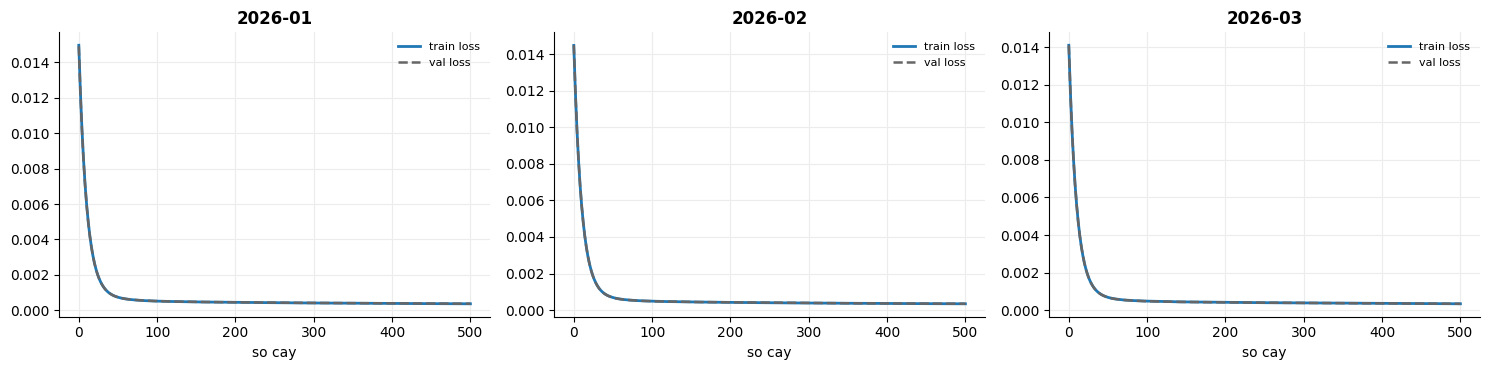

In [4]:
fig, axes = plt.subplots(1, len(thangs), figsize=(5*len(thangs), 3.8))
if len(thangs)==1: axes=[axes]
for ax, th in zip(axes, thangs):
    m=models[th]
    ax.plot(-np.array(m.train_score_), label="train loss", lw=2)
    ax.plot(-np.array(m.validation_score_), label="val loss", ls="--", lw=1.8, color="#666")
    ax.set_title(f"{th}", fontweight="bold"); ax.set_xlabel("so cay"); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

**4. Kết quả huấn luyện**

Gộp dự đoán test của cả 3 tháng, tính chỉ số: MAE, RMSE, R2.

In [5]:
allte = pd.concat(tests.values())
def metrics(y,p):
    y,p=np.asarray(y),np.asarray(p)
    return dict(MAE=mean_absolute_error(y,p), RMSE=mean_squared_error(y,p)**.5, R2=r2_score(y,p))
rows=[]
for th in thangs:
    te=tests[th]; mk=metrics(te[TARGET],te.pred); rows.append({"thang":th,"n":len(te),**mk})
mk_all=metrics(allte[TARGET],allte.pred); rows.append({"thang":"TAT CA","n":len(allte),**mk_all})
bang=pd.DataFrame(rows).round(4)
print("KET QUA MODEL HE SO NHAN:"); display(bang)

KET QUA MODEL HE SO NHAN:


,thang,n,MAE,RMSE,R2
0,2026-01,315360,0.0229,0.0350,0.9617
1,2026-02,234632,0.0234,0.0374,0.9590
2,2026-03,314368,0.0237,0.0365,0.9601
3,TAT CA,864360,0.0233,0.0362,0.9606


**5. Đánh giá**

So với baseline **persistence** (lấy y hệt quan sát gần nhất: `latest_observed_multiplier`) — mốc bắt buộc phải vượt.
Thêm: phân loại có surge (ROC-AUC), so hằng số 1.0.

MAE model      = 0.0233
MAE persistence= 0.0371 (latest_observed_multiplier)
MAE 'luon 1.0' = 0.2153

ROC-AUC (phan biet co surge) = 0.9978  (ty le surge nen 82.7%)


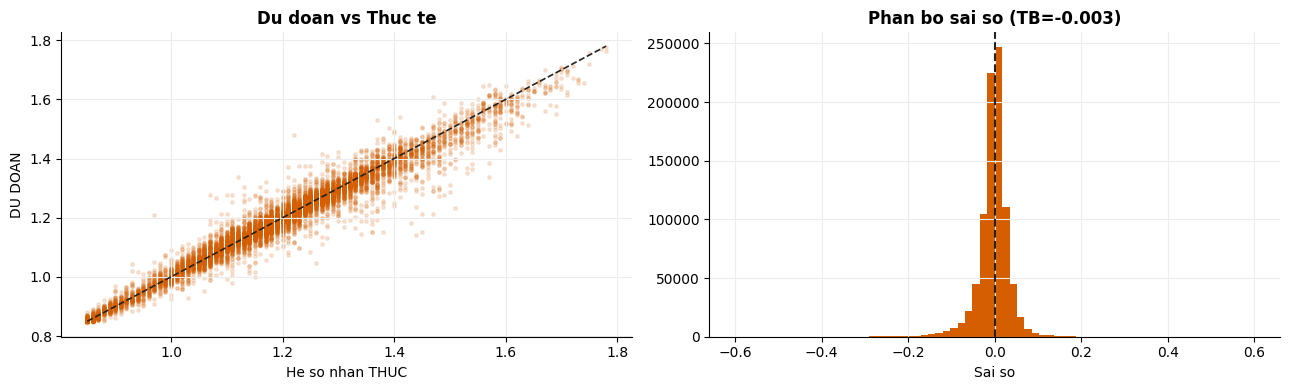

In [6]:
# vs baseline
per = mean_absolute_error(allte[TARGET], allte["latest_observed_multiplier"])
const = mean_absolute_error(allte[TARGET], np.ones(len(allte)))
mae = mean_absolute_error(allte[TARGET], allte.pred)
print(f"MAE model      = {mae:.4f}")
print(f"MAE persistence= {per:.4f} (latest_observed_multiplier)")
print(f"MAE 'luon 1.0' = {const:.4f}")
# Phan loai co surge
y_is=(allte[TARGET]>1).astype(int)
auc=roc_auc_score(y_is, allte.pred)
print(f"\nROC-AUC (phan biet co surge) = {auc:.4f}  (ty le surge nen {y_is.mean()*100:.1f}%)")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
s=allte.sample(min(8000,len(allte)), random_state=0)
ax[0].scatter(s[TARGET], s.pred, s=6, alpha=.15, color="#D55E00")
lim=[s[TARGET].min(),s[TARGET].max()]; ax[0].plot(lim,lim,"--",color="#222",lw=1.2)
ax[0].set_xlabel("He so nhan THUC"); ax[0].set_ylabel("DU DOAN"); ax[0].set_title("Du doan vs Thuc te", fontweight="bold")
err=allte.pred-allte[TARGET]
ax[1].hist(err, bins=70, range=(-.6,.6), color="#D55E00"); ax[1].axvline(0,color="#222",ls="--")
ax[1].set_xlabel("Sai so"); ax[1].set_title(f"Phan bo sai so (TB={err.mean():+.3f})", fontweight="bold")
plt.tight_layout(); plt.show()

**Lưu model**

In [ ]:
joblib.dump(models, "model_heso.joblib")
json.dump({"target":TARGET,"features":FEATS,"metrics":bang.to_dict("records")},
          open("ketqua_heso.json","w",encoding="utf-8"), ensure_ascii=False, indent=2, default=float)
print("Da luu model + ket qua.")

Da luu model + ket qua.


: 

**Kết luận**

Model HỆ SỐ NHÂN train theo từng tháng, đánh giá trên test chưa từng thấy. Với HCM có tín hiệu cung-cầu, model hệ so nhan ky vong tot hon Boston (Boston chạm trần do thiếu cung-cầu).

Bước tiếp theo: Uncertainty Quantification (Conformal Prediction) dùng tập `calibration` để xuất khoảng dự đoán.